In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.makedirs("../results/02", exist_ok = True)

In [2]:
df = pd.read_csv("../data/raw/TPD_OPEN_DATA_ReportedCrimesPublicDash.csv", low_memory = False)
df.shape

(251280, 14)

In [4]:
def parse_time_occur(val):
    "Parses the TimeOccur column to extract the hour of occurrence. Handles various formats and edge cases."
    if pd.isna(val):
        return np.nan
    s = str(val).strip().replace(":", "").zfill(4)
    if s.startswith("24"):
        return 0
    try:
        hour = int(s[:2])
        minute = int(s[2:])
        if 0 <= hour <= 23 and 0 <= minute <= 59:
            return hour
        else:
            return np.nan
    except ValueError:
        return np.nan

df["Hour"] = df["TimeOccur"].apply(parse_time_occur)

print(f"Parsed successfully: {df['Hour'].notna().sum()}")
print(f"Failed to parse: {df['Hour'].isna().sum()}")

Parsed successfully: 251280
Failed to parse: 0


In [6]:
df["Hour"].value_counts().sort_index()

Hour
0     13630
1      4954
2      4577
3      4078
4      3837
5      3920
6      4382
7      5786
8      8762
9      9905
10    13071
11    12862
12    15793
13    13738
14    14627
15    14782
16    14762
17    15147
18    14693
19    14018
20    13481
21    12070
22     9987
23     8418
Name: count, dtype: int64

In [7]:
df.isnull().sum()

IncidentID                0
DateOccurred              0
Year                      0
Month                     0
Day                       0
TimeOccur                 0
Division               3743
Ward                  15566
UCR                       0
UCRDescription            0
Offense                   0
OffenseDescription        0
CallSource             7408
ESRI_OID                  0
Hour                      0
dtype: int64

In [8]:
# dropping 2026 data as it is incomplete
df = df[df["Year"] != 2026]

# dropping rows where Division is missing 
df = df.dropna(subset=["Division"])
df = df[df["Division"] != "Other Jurisdiction"]

# filling Ward and CallSource 
df["Ward"] = df["Ward"].fillna(0).astype(str)
df["CallSource"] = df["CallSource"].fillna("Unknown")

# converting Hour to int
df["Hour"] = df["Hour"].astype(int)

# dropping columns we no longer need
df = df.drop(columns=["TimeOccur", "ESRI_OID", "DateOccurred"])

print(f"Final shape: {df.shape}")
print(df.isnull().sum())

Final shape: (243127, 12)
IncidentID            0
Year                  0
Month                 0
Day                   0
Division              0
Ward                  0
UCR                   0
UCRDescription        0
Offense               0
OffenseDescription    0
CallSource            0
Hour                  0
dtype: int64


In [9]:
df.to_csv("../data/processed/tpd_2018_2025.csv", index = False)
print("Saved.")

Saved.


In [11]:
df_clean = pd.read_csv("../data/processed/tpd_2018_2025.csv")

print(df_clean.shape)
print(df_clean.dtypes)
print(df_clean["UCRDescription"].value_counts())

(243127, 12)
IncidentID             object
Year                    int64
Month                  object
Day                    object
Division               object
Ward                  float64
UCR                     int64
UCRDescription         object
Offense                 int64
OffenseDescription     object
CallSource             object
Hour                    int64
dtype: object
UCRDescription
06 - LARCENY                170264
05 - BURGLARY                21409
07 - GTA                     19227
04 - ASSAULT, AGGRAVATED     18465
03 - ROBBERY                  8188
02 - SEXUAL ASSAULT           3534
08 - ARSON                    1512
01 - HOMICIDE                  528
Name: count, dtype: int64


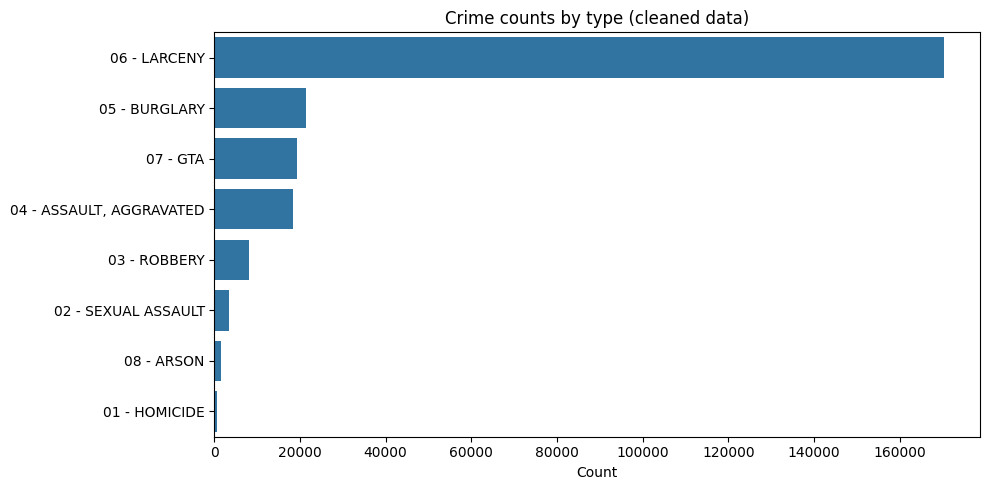

In [13]:
plt.figure(figsize = (10, 5))
order = df_clean["UCRDescription"].value_counts().index
sns.countplot(data = df_clean, y = "UCRDescription", order = order)
plt.title("Crime counts by type (cleaned data)")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../results/02/crime_counts_by_type_clean.png", dpi = 150, bbox_inches = "tight")
plt.show()

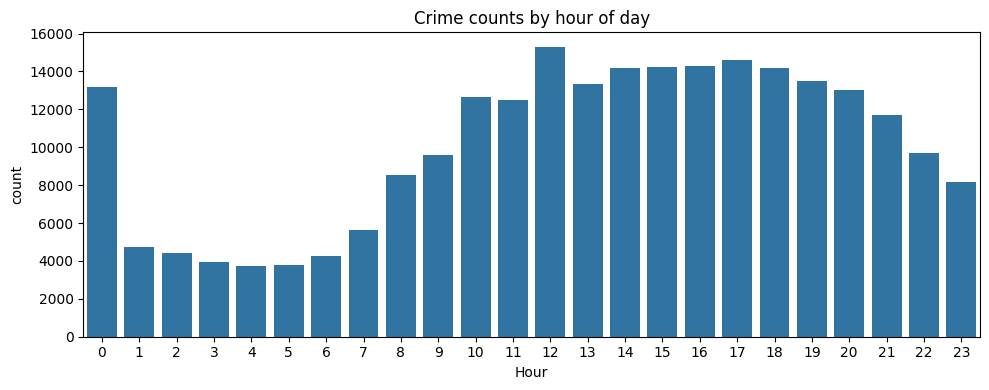

In [14]:
plt.figure(figsize = (10, 4))
sns.countplot(data = df_clean, x = "Hour")
plt.title("Crime counts by hour of day")
plt.tight_layout()
plt.savefig("../results/02/crime_counts_by_hour.png", dpi = 150, bbox_inches = "tight")
plt.show()

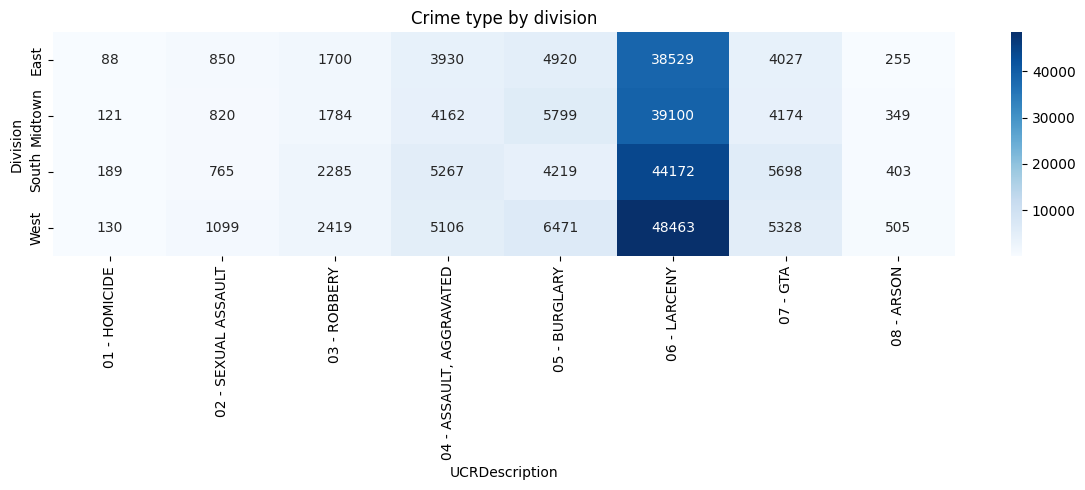

In [15]:
pivot = df_clean.groupby(["Division", "UCRDescription"]).size().unstack(fill_value = 0)
plt.figure(figsize = (12, 5))
sns.heatmap(pivot, annot = True, fmt = "d", cmap = "Blues")
plt.title("Crime type by division")
plt.tight_layout()
plt.savefig("../results/02/crime_type_by_division_heatmap.png", dpi = 150, bbox_inches = "tight")
plt.show()

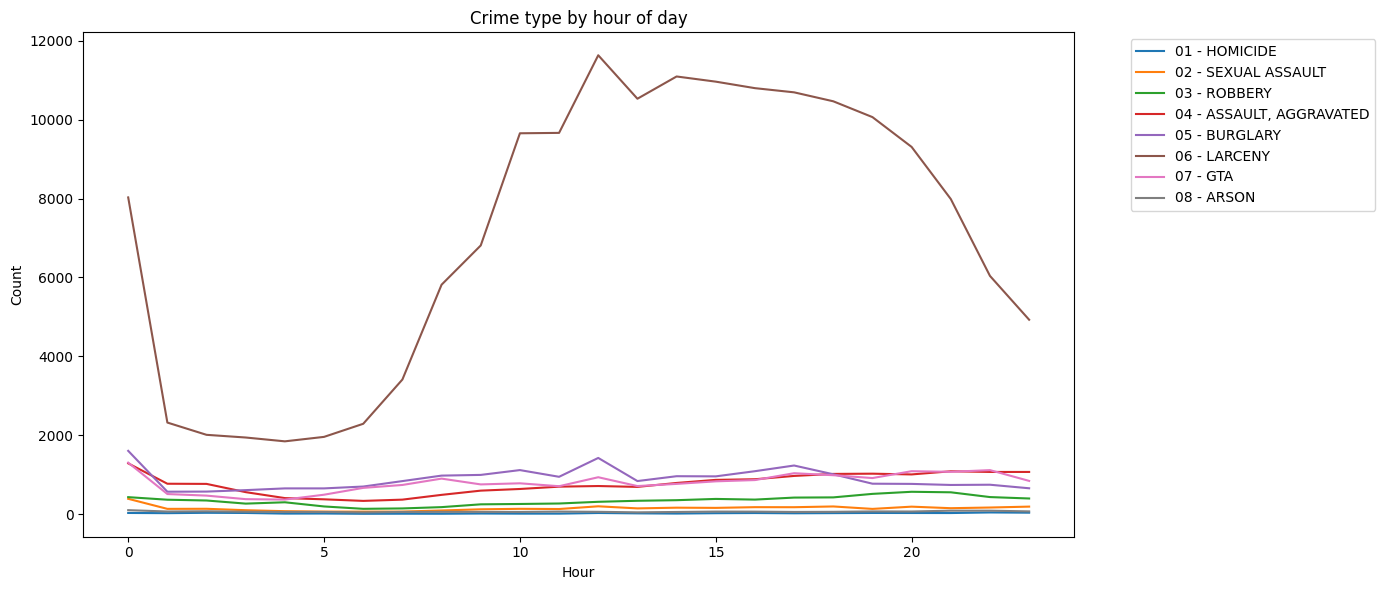

In [16]:
pivot = df_clean.groupby(["Hour", "UCRDescription"]).size().unstack(fill_value = 0)
pivot.plot(kind = "line", figsize = (14, 6))
plt.title("Crime type by hour of day")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.legend(bbox_to_anchor = (1.05, 1), loc = "upper left")
plt.tight_layout()
plt.savefig("../results/02/crime_type_by_hour.png", dpi = 150, bbox_inches = "tight")
plt.show()

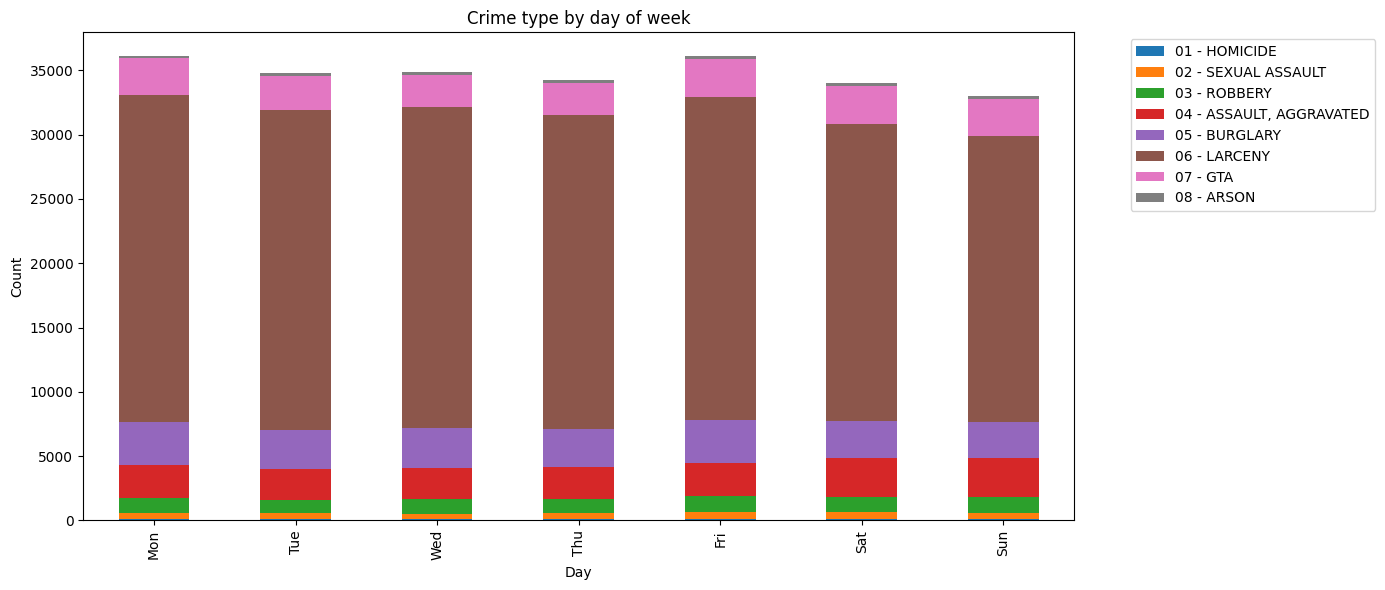

In [17]:
pivot = df_clean.groupby(["Day", "UCRDescription"]).size().unstack(fill_value = 0)
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
pivot = pivot.reindex(day_order)
pivot.plot(kind = "bar", figsize = (14, 6), stacked = True)
plt.title("Crime type by day of week")
plt.xlabel("Day")
plt.ylabel("Count")
plt.legend(bbox_to_anchor = (1.05, 1), loc = "upper left")
plt.tight_layout()
plt.savefig("../results/02/crime_type_by_day.png", dpi = 150, bbox_inches = "tight")
plt.show()

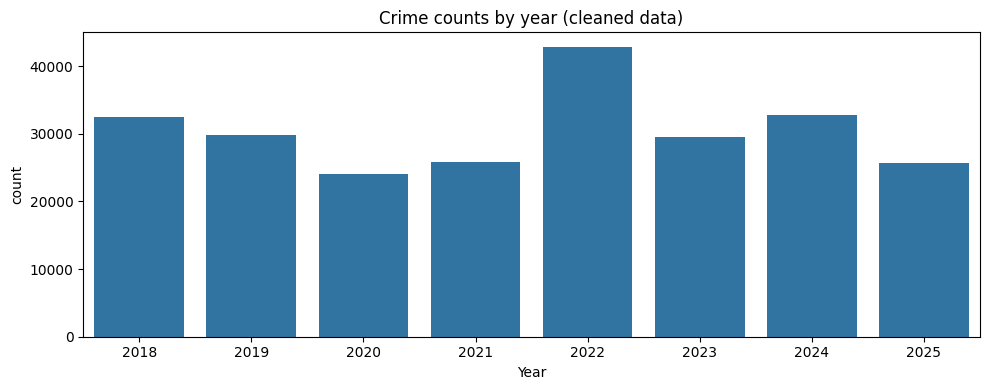

In [18]:
plt.figure(figsize = (10, 4))
sns.countplot(data = df_clean, x = "Year")
plt.title("Crime counts by year (cleaned data)")
plt.tight_layout()
plt.savefig("../results/02/crime_counts_by_year_clean.png", dpi = 150, bbox_inches = "tight")
plt.show()

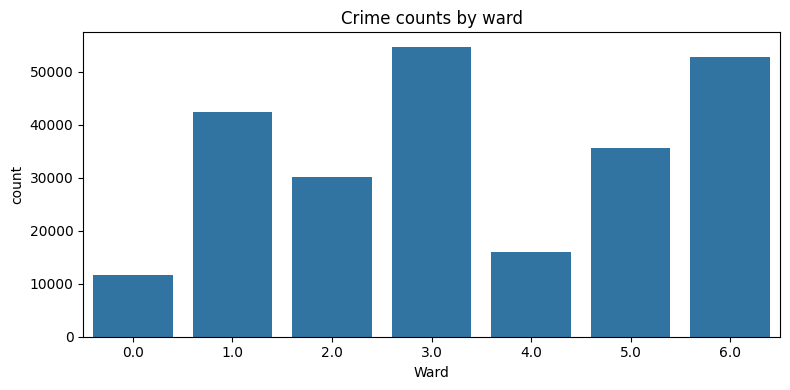

In [19]:
plt.figure(figsize = (8, 4))
sns.countplot(data = df_clean, x = "Ward")
plt.title("Crime counts by ward")
plt.tight_layout()
plt.savefig("../results/02/crime_counts_by_ward.png", dpi = 150, bbox_inches = "tight")
plt.show()

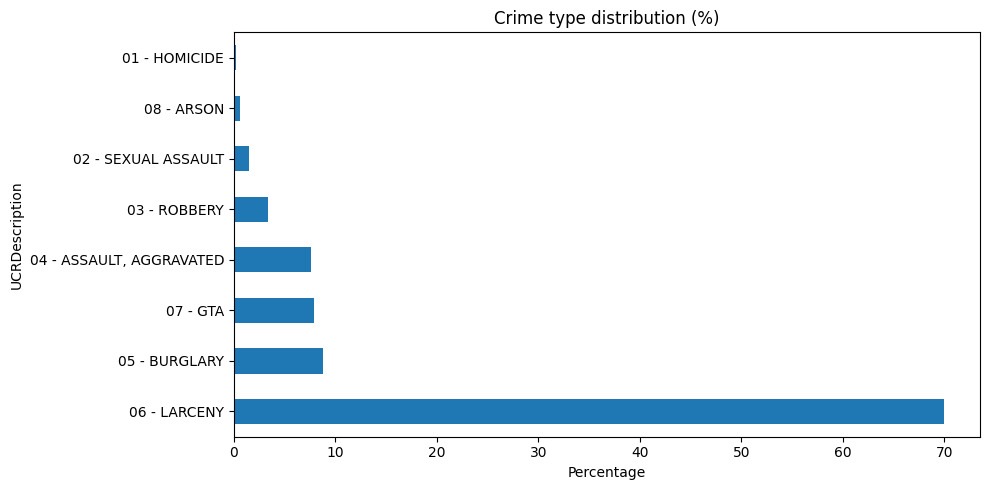

In [20]:
plt.figure(figsize = (10, 5))
pct = df_clean["UCRDescription"].value_counts(normalize = True) * 100
pct.plot(kind = "barh")
plt.title("Crime type distribution (%)")
plt.xlabel("Percentage")
plt.tight_layout()
plt.savefig("../results/02/crime_type_percentage.png", dpi = 150, bbox_inches = "tight")
plt.show()

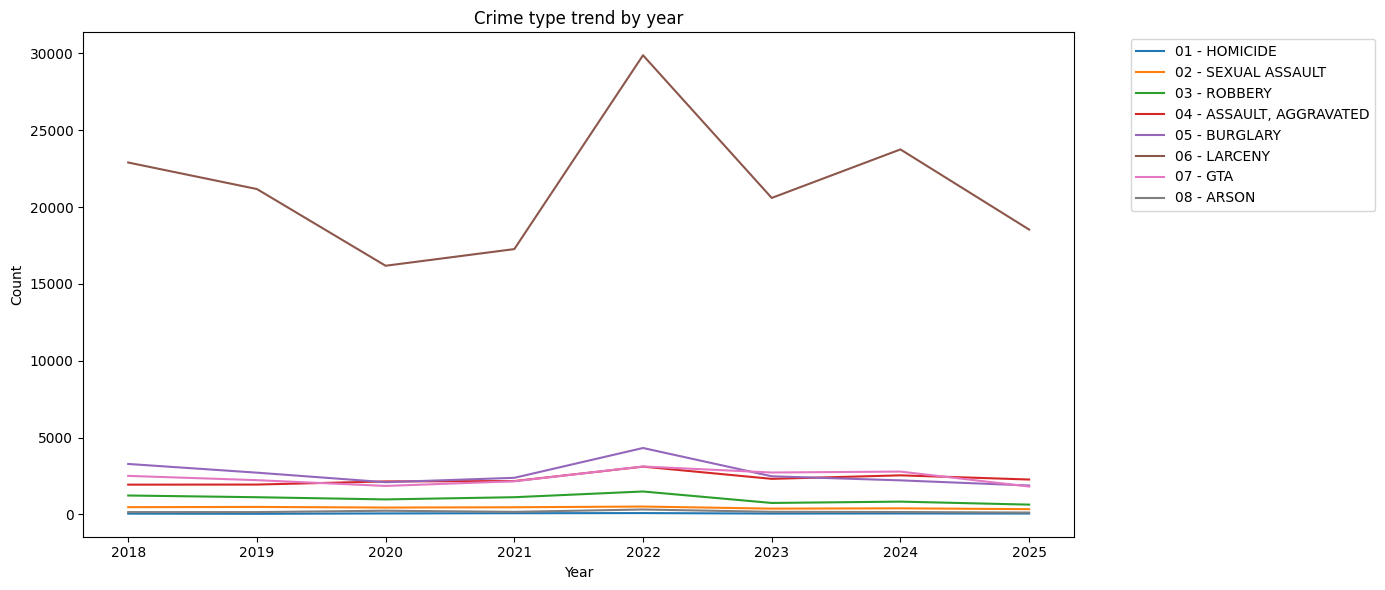

In [21]:
pivot = df_clean.groupby(["Year", "UCRDescription"]).size().unstack(fill_value = 0)
pivot.plot(kind = "line", figsize = (14, 6))
plt.title("Crime type trend by year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(bbox_to_anchor = (1.05, 1), loc = "upper left")
plt.tight_layout()
plt.savefig("../results/02/crime_type_trend_by_year.png", dpi = 150, bbox_inches = "tight")
plt.show()

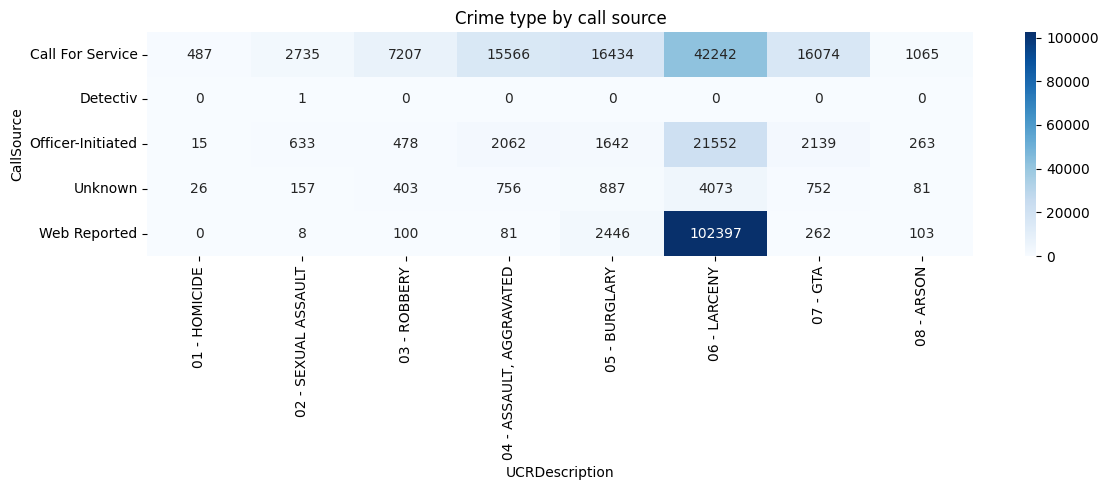

In [22]:
pivot = df_clean.groupby(["CallSource", "UCRDescription"]).size().unstack(fill_value = 0)
plt.figure(figsize = (12, 5))
sns.heatmap(pivot, annot = True, fmt = "d", cmap = "Blues")
plt.title("Crime type by call source")
plt.tight_layout()
plt.savefig("../results/02/crime_type_by_callsource.png", dpi = 150, bbox_inches = "tight")
plt.show()

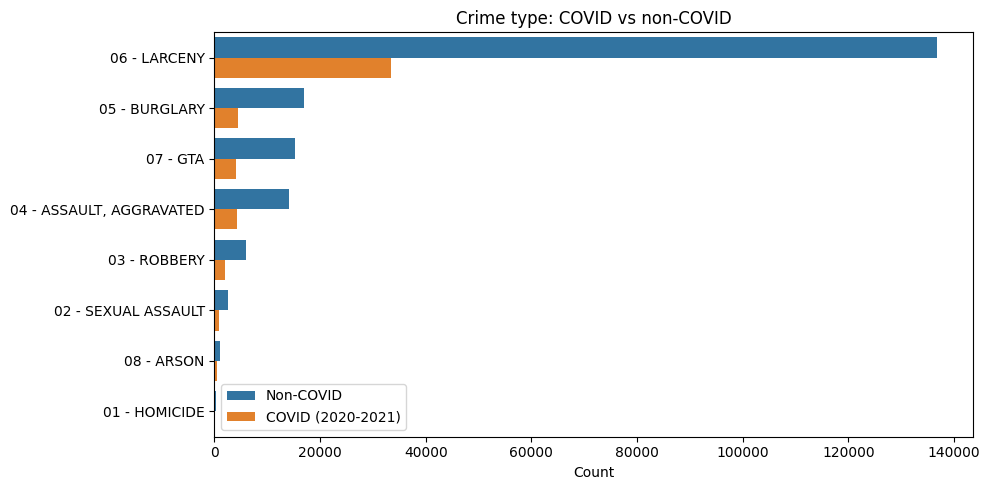

In [25]:
covid_years = [2020, 2021]
df_clean["Period"] = df_clean["Year"].apply(lambda x: "COVID (2020-2021)" if x in covid_years else "Non-COVID")

plt.figure(figsize = (10, 5))
order = df_clean["UCRDescription"].value_counts().index
sns.countplot(data = df_clean, y = "UCRDescription", hue = "Period", order = order)
plt.title("Crime type: COVID vs non-COVID")
plt.xlabel("Count")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.savefig("../results/02/crime_type_covid_vs_noncovid.png", dpi = 150, bbox_inches = "tight")
plt.show()

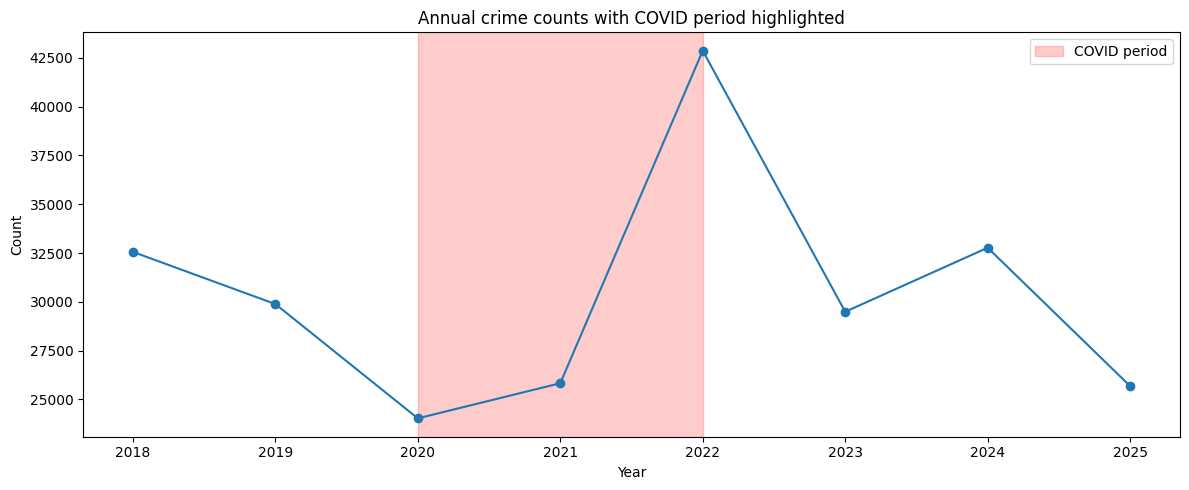

In [27]:
monthly = df_clean.groupby("Year").size()
plt.figure(figsize = (12, 5))
monthly.plot(kind = "line", marker = "o")
plt.axvspan(2020, 2022, alpha = 0.2, color = "red", label = "COVID period")
plt.title("Annual crime counts with COVID period highlighted")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("../results/02/crime_trend_covid_highlighted.png", dpi = 150, bbox_inches = "tight")
plt.show()